In [ ]:
# منار تركي أحمد - شعبة2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import roc_curve, auc
from sklearn.impute import SimpleImputer

In [ ]:
# import the data set using the cood in the websit (data websit)
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes)
X = adult.data.features
y = adult.data.targets

# metadata
print(adult.metadata)

# variable information
print(adult.variables)

print(X.head())
print(X.info())
print(X.describe())

print(y.info())

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [ ]:
# handeling missing data by replace NAN -> mode
categorical_cols = ['workclass', 'occupation', 'native-country']
imputer = SimpleImputer(strategy='most_frequent')
X[categorical_cols] = imputer.fit_transform(X[categorical_cols])

# make sure that all missing value are replaced
print(X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48842 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB
None


/tmp/ipython-input-676787803.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[categorical_cols] = imputer.fit_transform(X[categorical_cols])


In [ ]:
# encoding all categorical coulm using one hot
numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation','relationship', 'race', 'sex', 'native-country']

preprocessor = ColumnTransformer(transformers=[ ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols) ],
    remainder='passthrough' ) # keep numeric coulm without change
#apply the encoding
X_encoded = preprocessor.fit_transform(X)
if hasattr(X_encoded, "toarray"):
    X_encoded = X_encoded.toarray()
encoded_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_cols = list(encoded_cols) + numeric_cols

#  new DataFrame
X_encoded_df = pd.DataFrame(X_encoded, columns=all_cols)
print(X_encoded_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Columns: 108 entries, workclass_? to hours-per-week
dtypes: float64(108)
memory usage: 40.2 MB
None


In [ ]:
# convert the target coulm becase the model can not handel nan num value
y =  y['income'].copy()
y = y.str.strip()
y = y.str.replace('.', '', regex=False)
y = y.replace({'<=50K': 0, '>50K': 1})
y = y.astype(int)

print("Unique values:", y.unique())      # [0, 1]
print("Data type:", y.dtype)             # int64
print("Value counts:\n", y.value_counts())


Unique values: [0 1]
Data type: int64
Value counts:
 income
0    37155
1    11687
Name: count, dtype: int64


/tmp/ipython-input-2195079560.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'<=50K': 0, '>50K': 1})


In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded_df, y, test_size=0.30, random_state=0, stratify=y
)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))
# we see that the data are not balanc so the model predict wrong

income
0    0.760713
1    0.239287
Name: proportion, dtype: float64
income
0    0.760732
1    0.239268
Name: proportion, dtype: float64


model1:
Predicted labels: [0 1 0 ... 0 0 0]
Accuracy: 0.8100047771787348

Classification Report:
               precision    recall  f1-score   support

       <=50K       0.95      0.79      0.86     11147
        >50K       0.57      0.86      0.68      3506

    accuracy                           0.81     14653
   macro avg       0.76      0.83      0.77     14653
weighted avg       0.86      0.81      0.82     14653



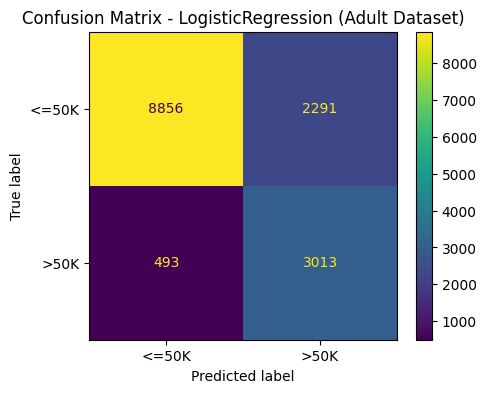

In [ ]:
# LogisticRegression
# standerdize to incareas the performans
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Model building and training for LogisticRegression
model1 = LogisticRegression(max_iter=5000, class_weight='balanced')# to make the data balanc
model1.fit(X_train_scaled, y_train)


print("model1:")
# Make Predictions for model1 (LogisticRegression)
y_pred1= model1.predict(X_test_scaled)
print("Predicted labels:", y_pred1)

# Evaluate the Model1 for (LogisticRegression)
accuracy = accuracy_score(y_test, y_pred1)
print("Accuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred1, target_names=['<=50K', '>50K']))

# Confusion Matrix for LogisticRegression
labels = ['<=50K', '>50K']
cm = confusion_matrix(y_test, y_pred1)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax)
plt.title("Confusion Matrix - LogisticRegression (Adult Dataset)")
plt.show()

model2:
Predicted labels: [0 0 0 ... 0 0 0]
Accuracy: 0.7970381491844674

Classification report:

              precision    recall  f1-score   support

       <=50K       0.82      0.95      0.88     11147
        >50K       0.66      0.32      0.43      3506

    accuracy                           0.80     14653
   macro avg       0.74      0.63      0.65     14653
weighted avg       0.78      0.80      0.77     14653



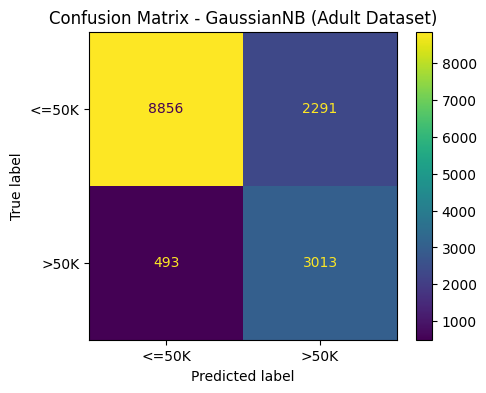

In [ ]:
# Model building and training for GaussianNB
model2 = GaussianNB()
model2.fit(X_train, y_train)

print("model2:")
# Make Predictions for model2 (GaussianNB)
y_pred2 = model2.predict(X_test)
print("Predicted labels:", y_pred2)

# Evaluate the Model2 for (GaussianNB)
accuracy2 = accuracy_score(y_test, y_pred2)
print("Accuracy:", accuracy2)
print("\nClassification report:\n")
print(classification_report(y_test, y_pred2, target_names=['<=50K', '>50K']))

# Confusion Matrix for LogisticRegression
labels = ['<=50K', '>50K']
cm = confusion_matrix(y_test, y_pred1)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax)
plt.title("Confusion Matrix - GaussianNB (Adult Dataset)")
plt.show()

model3:
Predicted labels: [0 1 1 ... 1 1 0]
Accuracy: 0.7600491366955572

Classification Report (Precision, Recall, F1-Score):
              precision    recall  f1-score   support

           0       0.92      0.75      0.83     11147
           1       0.50      0.79      0.61      3506

    accuracy                           0.76     14653
   macro avg       0.71      0.77      0.72     14653
weighted avg       0.82      0.76      0.78     14653



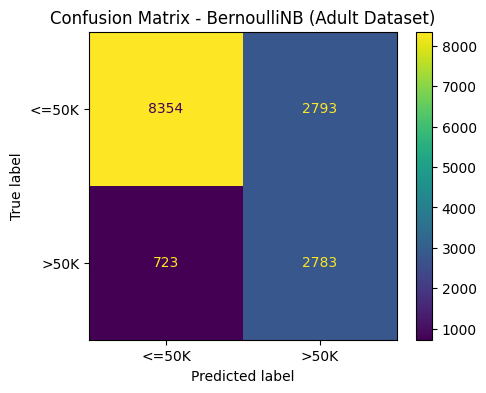

In [ ]:
# Model building and training for BernoulliNB
model3 = BernoulliNB()
model3.fit(X_train, y_train)

print("model3:")
#Make Predictions for model3 (BernoulliNB)
y_pred3 = model3.predict(X_test)
y_proba3 = model3.predict_proba(X_test)[:, 1]
print("Predicted labels:", y_pred3)

#Evaluate the Model2 for (BernoulliNB)
accuracy3 = accuracy_score(y_test, y_pred3)
print("Accuracy:", accuracy3)

print("\nClassification Report (Precision, Recall, F1-Score):")
print(classification_report(y_test, y_pred3, zero_division=0))

# Confusion Matrix for BernoulliNB
labels = ['<=50K', '>50K']
cm = confusion_matrix(y_test, y_pred3)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax)
plt.title("Confusion Matrix - BernoulliNB (Adult Dataset)")
plt.show()

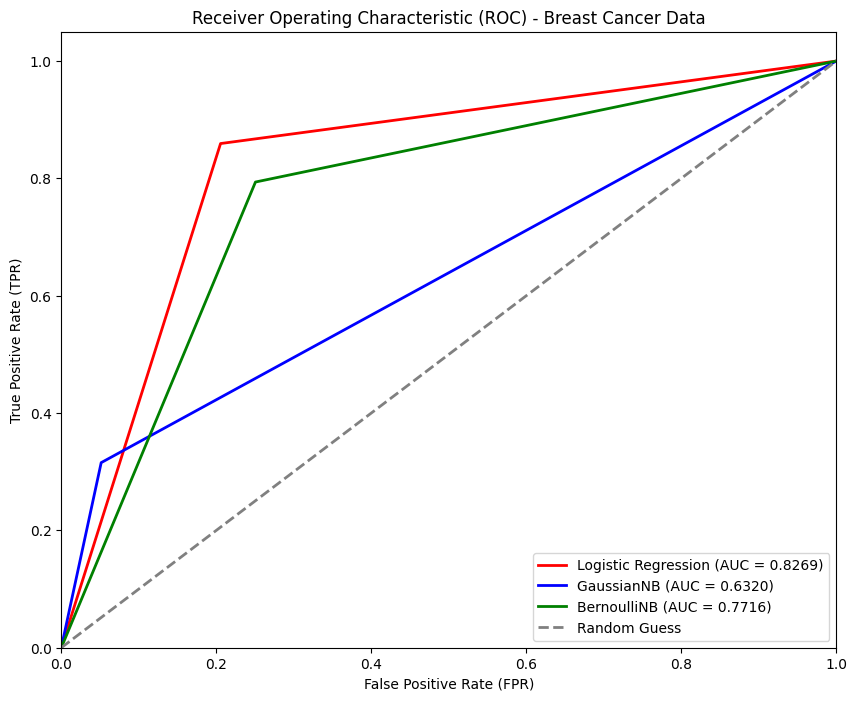

In [ ]:
#plot ROC for all models
fpr_model1, tpr_model1, thresholds_model1 = roc_curve(y_test, y_pred1)
roc_auc_model1 = auc(fpr_model1, tpr_model1)

fpr_model2, tpr_model2, thresholds_model2 = roc_curve(y_test, y_pred2)
roc_auc_model2 = auc(fpr_model2, tpr_model2)

fpr_model3, tpr_model3, thresholds_model3 = roc_curve(y_test, y_pred3)
roc_auc_model3 = auc(fpr_model3, tpr_model3)

plt.figure(figsize=(10, 8))
plt.plot(fpr_model1, tpr_model1, color='red', lw=2,
         label='Logistic Regression (AUC = %0.4f)' % roc_auc_model1)
plt.plot(fpr_model2, tpr_model2, color='blue', lw=2,
         label='GaussianNB (AUC = %0.4f)' % roc_auc_model2)
plt.plot(fpr_model3, tpr_model3, color='green', lw=2,
         label='BernoulliNB (AUC = %0.4f)' % roc_auc_model3)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) - Breast Cancer Data')
plt.legend(loc="lower right")

Comparative Analaysis:
1. All three models did not give very high performance because they were not very suitable for the data, but the Logistic model gave the highest performance because even after encoding, it was able to draw a line that separates the classes and did that reasonably well.
Bernoulli gave the second-best performance achieved the lowest accuracy, but performance was actually better than Gaussian, as its results showed, because after encoding, all the data became binary, which fits it to some extent—although some details were lost during encoding. However, unlike Logistic Regression, it does not assign or learn weights; instead, it assumes independence like Gaussian so this why it’s performance not the best.
Gaussian was the worst, gave an average accuracy, but the reality is that it did not predict correctly, and its performance was weak because it works with continuous numerical data, but here the data had to be encoded. Furthermore, the data distribution was not normal, so the model could not learn and predict well.
2. The data aims to predict whether a person’s income is greater or less than 50,000 dollars per year, but the problem is that this data is not numerical; it is a mix of categorical and numerical values. The models I used only accept or work with numerical values, so I had to encode all the categorical rows, and this affected the models as follows:
The Logistic model tried to draw a line separating the two classes and handled the values well. I also applied standardization and made the data balanced so that the model would not be biased toward one value over the other. In general, the Logistic model tried well to give weight to each column and draw an approximate line.
Bernoulli basically depends on the features being binary, so after encoding, the data became theoretically suitable. However, Bernoulli does not learn weights but assumes that the columns are independent, while the data was correlated. Also, the encoding removed some details from the data, so the model gave average performance because the data type matched it only slightly.
Gaussian works with continuous data, so the data after encoding was not suitable for it at all, and therefore it gave poor results.
3. When I prepared and cleaned the data, I first examined it to identify any problems. It contained missing values and also needed encoding. For the missing values, I had two options: to delete them or to fill them. Since the dataset was not very large and the missing values were not too many, the best solution was to fill them with the most frequent values (mode). If I had deleted them, the data would have been greatly affected, and the models could have overfitted.
Then, I encoded all the categorical data while keeping the numerical data as it was. I only applied standardization in the Logistic model because the other two models were negatively affected by it and their performance decreased. I also noticed that the data, specifically the target column, was not balanced, so I balanced it to prevent the Logistic model from being biased toward one class over the other. All these steps improved the performance and accuracy as much as possible.
4. Honestly, I cannot recommend any model yet because the performance needs to be improved using more advanced methods or by choosing models that are more suitable for this type of data. For example, the Gaussian model would have given much better results if I had used a different encoding method instead of One-Hot Encoding. I am also sure there are ways to improve the performance a little since the data is not the best fit for these models, but the accuracy can be enhanced. However, I prefer to use different models that are more suitable for this type of data like random forest.